<a href="https://colab.research.google.com/github/Mangesh0309/ML_Basics/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PART-1: THEORTICAL QUESTIONS

Q1. What is unsupervised learning?

Answer:
Unsupervised learning is a type of machine learning where the model learns patterns from unlabeled data. The goal is to discover hidden structures such as clusters or groupings without predefined output labels.
 Example: Customer segmentation.

Q2. How does K-Means clustering work?

Answer:
K-Means works by:

Selecting K initial centroids

Assigning each data point to the nearest centroid

Updating centroids as the mean of assigned points

Repeating until centroids stabilize
 It minimizes inertia (within-cluster variance).

Q3. What is a dendrogram?

Answer:
A dendrogram is a tree-like diagram that shows how data points are merged or split in hierarchical clustering.
 Height shows distance between clusters.

Q4. Difference between K-Means and Hierarchical Clustering?

Answer:
K-Means requires predefined K and is faster, while Hierarchical clustering does not require K initially and produces a dendrogram but is computationally expensive.

Q5. Advantages of DBSCAN over K-Means?

Answer:
DBSCAN:

Finds clusters of arbitrary shape

Does not require number of clusters

Identifies noise/outliers explicitly
 Better for real-world messy data.

Q6. When is Silhouette Score used?

Answer:
Silhouette Score is used to evaluate clustering quality by measuring how well a point fits within its cluster compared to others.
Range: -1 to +1.

Q7. Limitations of Hierarchical Clustering?

Answer:

High time and space complexity

Sensitive to noise

Cannot undo previous merges

Q8. Why is feature scaling important?

Answer:
Clustering algorithms use distance metrics. Without scaling, features with larger values dominate, leading to incorrect clusters.

Q9. How does DBSCAN identify noise?

Answer:
Points that do not have at least min_samples neighbors within distance eps are labeled as noise (-1).

Q10. What is inertia in K-Means?

Answer:
Inertia is the sum of squared distances between data points and their nearest cluster centroid. Lower inertia = tighter clusters.

Q11. What is the Elbow Method?

Answer:
It plots inertia vs number of clusters and identifies the point where improvement slows down (the “elbow”).

Q12. Density in DBSCAN?

Answer:
Density refers to the number of data points within a neighborhood (eps). Dense regions form clusters.

Q13. Can hierarchical clustering handle categorical data?

Answer:
Yes, but only if a suitable distance metric (like Hamming distance) is used.

Q14. What does negative Silhouette Score mean?

Answer:
It indicates that a data point may be assigned to the wrong cluster.

Q15. Linkage criteria?

Answer:
It defines how distance between clusters is calculated (single, complete, average, ward).

Q16. Why K-Means fails with varying densities?

Answer:
K-Means assumes spherical clusters of similar size and density, which breaks for uneven data.

Q17. Core parameters of DBSCAN?

Answer:

eps: neighborhood radius

min_samples: minimum points to form a dense region

Q18. K-Means++ improvement?

Answer:
K-Means++ initializes centroids far apart, leading to faster convergence and better clusters.

Q19. What is agglomerative clustering

Answer:

Agglomerative clustering is a bottom-up hierarchical clustering method where:

Each data point starts as its own cluster

The closest clusters are repeatedly merged

Q20. What makes Silhouette Score a better metric than just inertia for model evaluation?

Answer:
Inertia always decreases with K, but Silhouette Score measures separation + cohesion, making it more reliable.

# PART-2: PRACTICAL QUESTIONS

Q21. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score.

Silhouette Score: 0.6771943882143446


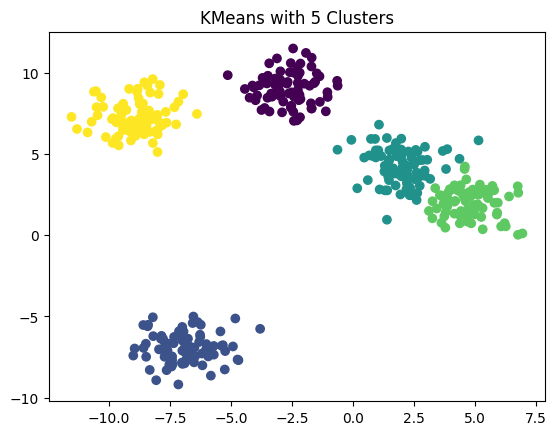

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
X, _ = make_blobs(n_samples=400, centers=5, random_state=42)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("KMeans with 5 Clusters")
plt.show()

Q22. Load the Breast Cancer dataset, apply PCA, and Agglomerative Clustering.

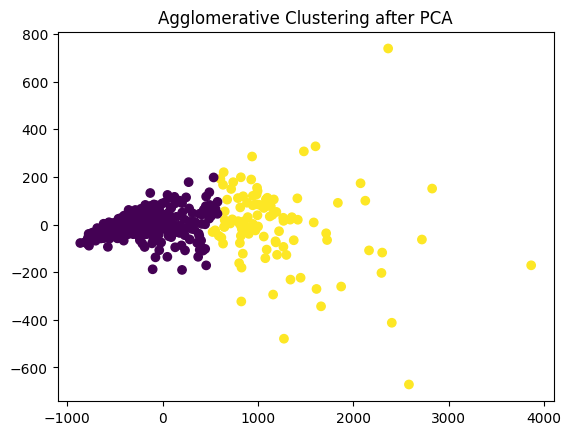

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Agglomerative Clustering after PCA")
plt.show()

Q23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot

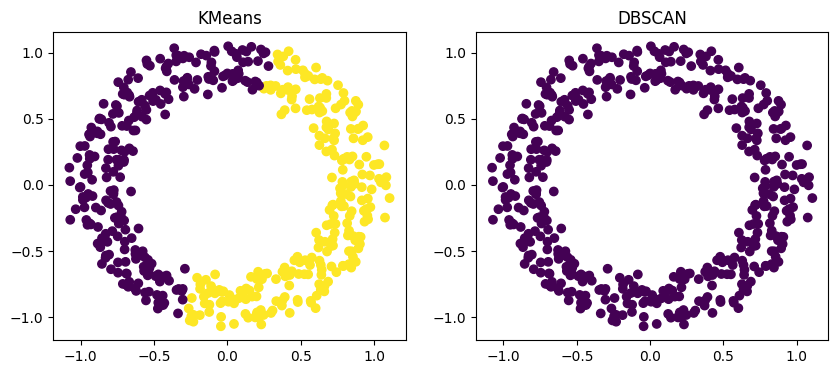

In [3]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=500, noise=0.05)

kmeans = KMeans(n_clusters=2)
k_labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=0.2)
d_labels = dbscan.fit_predict(X)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=k_labels)
plt.title("KMeans")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=d_labels)
plt.title("DBSCAN")

plt.show()

Q24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each
cluster

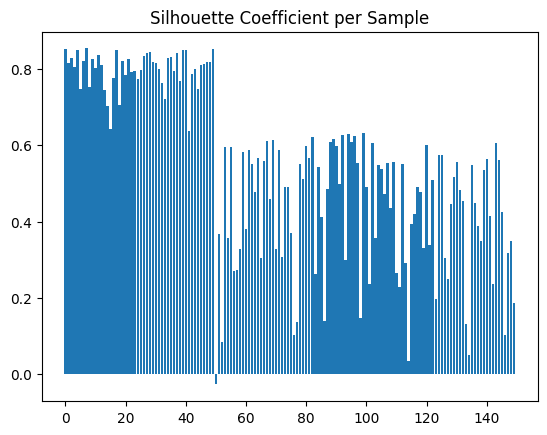

In [4]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

X = load_iris().data

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

sil_values = silhouette_samples(X, labels)

plt.bar(range(len(sil_values)), sil_values)
plt.title("Silhouette Coefficient per Sample")
plt.show()

Q25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result

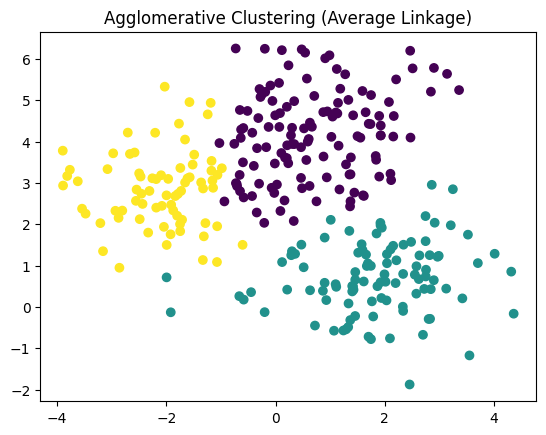

In [5]:
X, _ = make_blobs(n_samples=300, centers=3, random_state=0)

agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

Q26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster
centroids

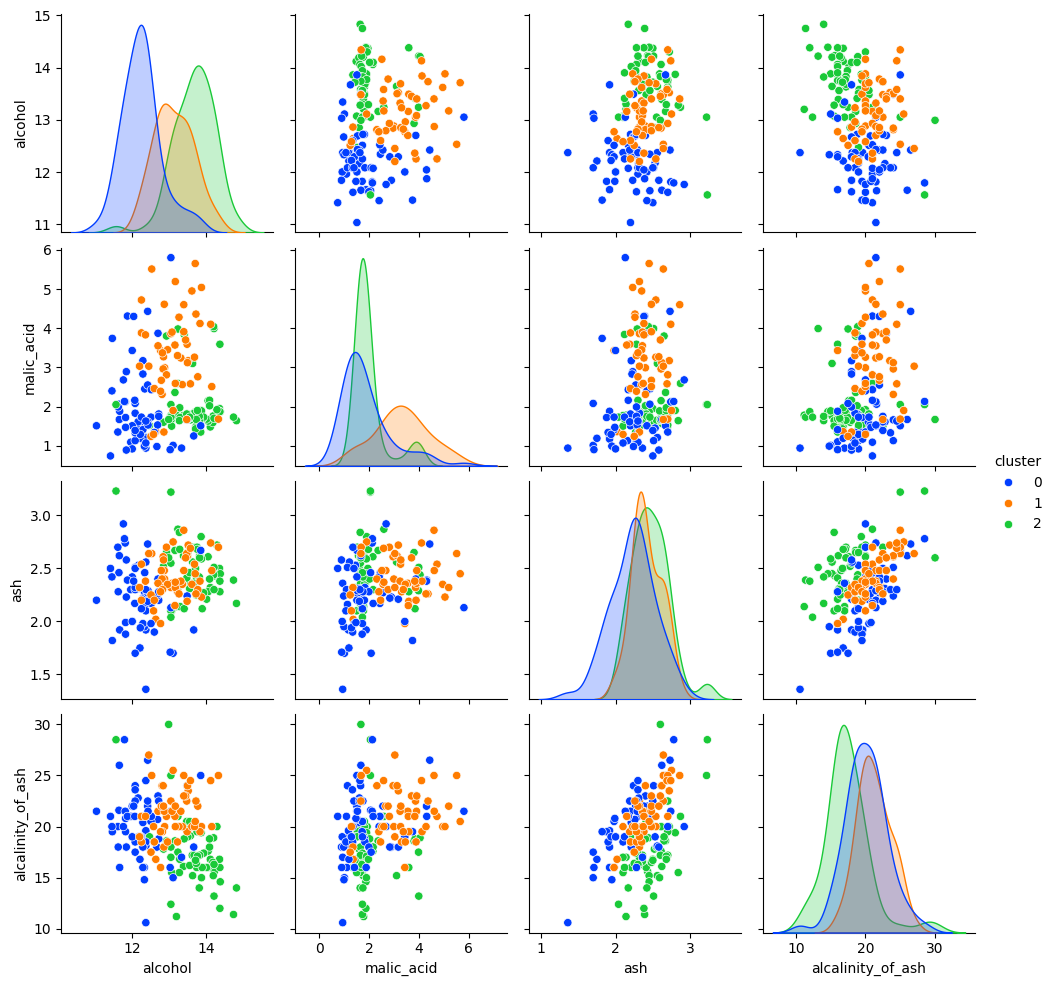

In [6]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Added for better accuracy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. Scale the data (Standardization)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. Apply KMeans
# We use 3 clusters because the wine dataset has 3 known types
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled_data)

# 4. Visualize using Pairplot
# We'll take the first 4 features plus the cluster column
cols_to_plot = list(df.columns[:4]) + ['cluster']
sns.pairplot(df[cols_to_plot], hue='cluster', palette='bright')
plt.show()

Q27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with
DBSCAN

Noise points: 135


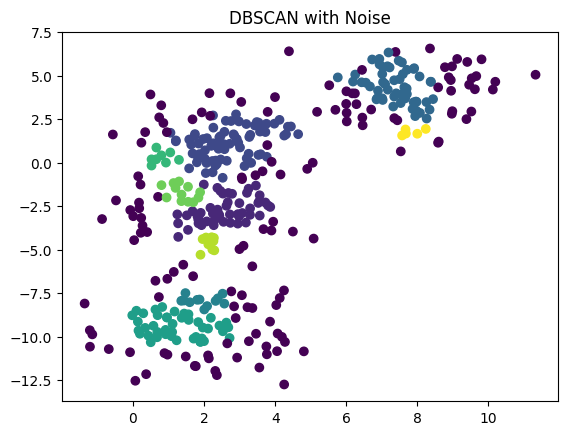

In [7]:
X, _ = make_blobs(n_samples=400, centers=4, cluster_std=1.2)

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

noise = list(labels).count(-1)
print("Noise points:", noise)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN with Noise")
plt.show()

Q28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means

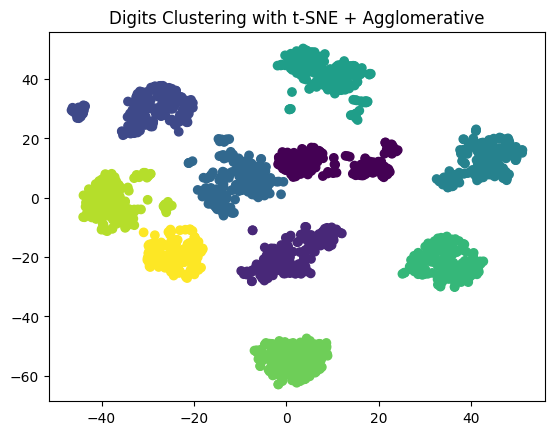

In [8]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

digits = load_digits()
X = digits.data

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

agg = AgglomerativeClustering(n_clusters=10)
labels = agg.fit_predict(X_tsne)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels)
plt.title("Digits Clustering with t-SNE + Agglomerative")
plt.show()

Q29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart

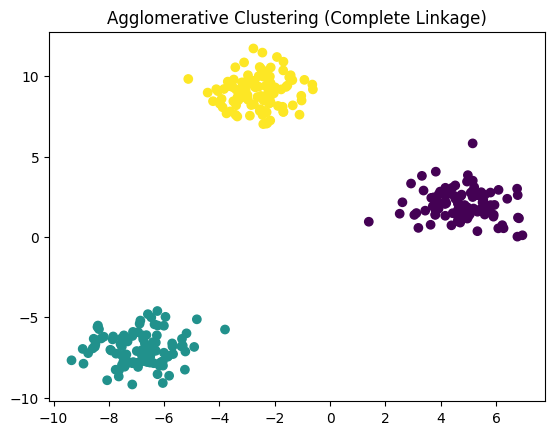

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

Q30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage

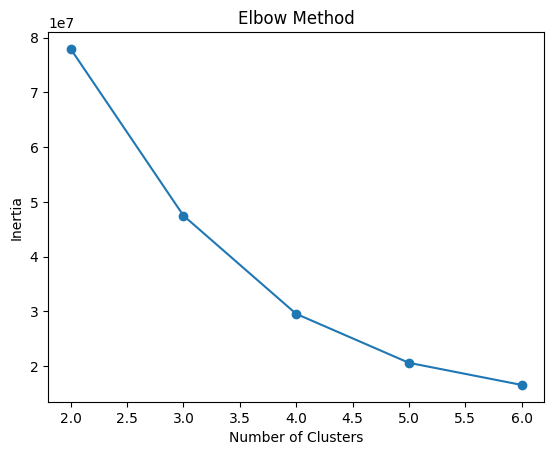

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_breast_cancer().data

inertia = []
K = range(2,7)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Q31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with
decision boundaries

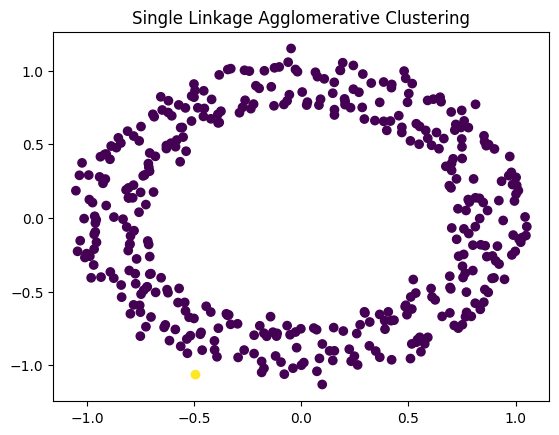

In [11]:
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=400, noise=0.05)

agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Single Linkage Agglomerative Clustering")
plt.show()

Q32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results

In [12]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

X = load_wine().data
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=1.5, min_samples=5)
labels = db.fit_predict(X_scaled)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", clusters)

Number of clusters: 0


Q33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot
the result

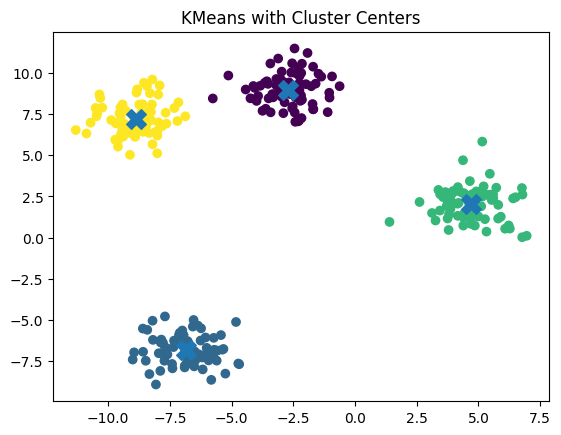

In [13]:
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker='X')
plt.title("KMeans with Cluster Centers")
plt.show()

Q34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a
line plot

In [14]:
from sklearn.datasets import load_iris

X = load_iris().data
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

noise = list(labels).count(-1)
print("Noise samples:", noise)

Noise samples: 34


Q35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with
single linkage

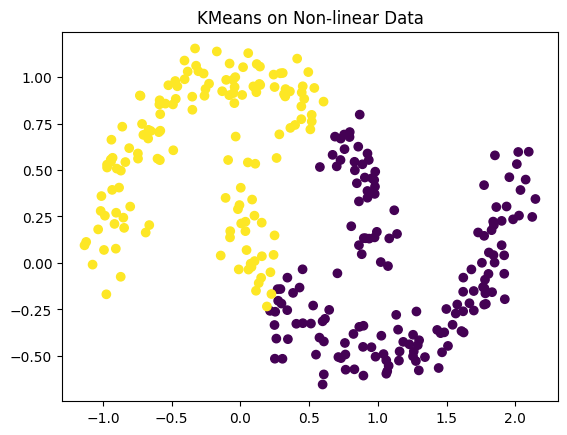

In [15]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.1)

kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("KMeans on Non-linear Data")
plt.show()

Q36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)

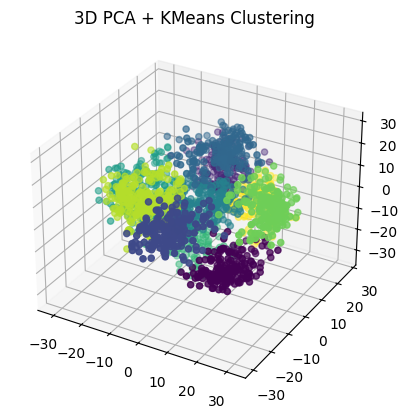

In [16]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
X = digits.data

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)
ax.set_title("3D PCA + KMeans Clustering")
plt.show()

Q37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the
data points

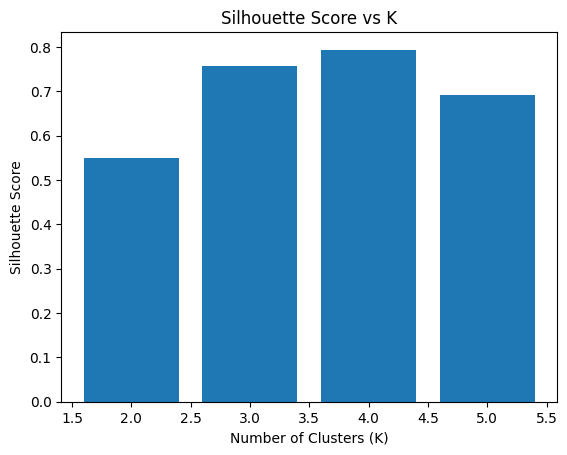

In [17]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=400, centers=4, random_state=42)

scores = []
K = range(2,6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.bar(K, scores)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

Q38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise

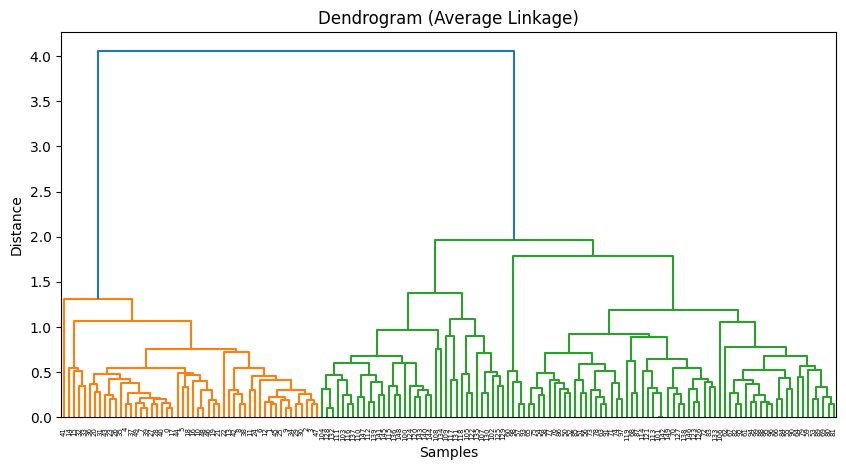

In [18]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X = load_iris().data

Z = linkage(X, method='average')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram (Average Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

Q39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the
clustering result

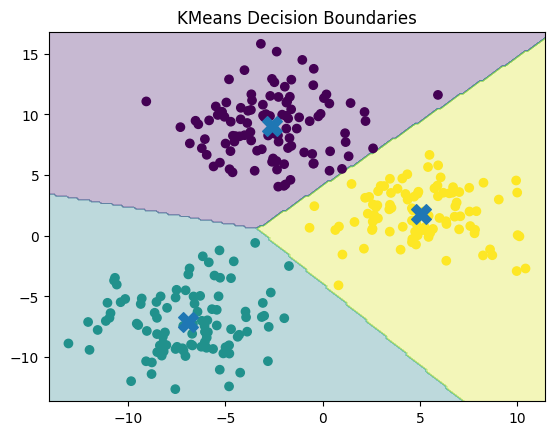

In [19]:
import numpy as np
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5, random_state=42)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min,x_max,200),
                     np.linspace(y_min,y_max,200))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker='X')
plt.title("KMeans Decision Boundaries")
plt.show()

Q40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D
scatter plot.

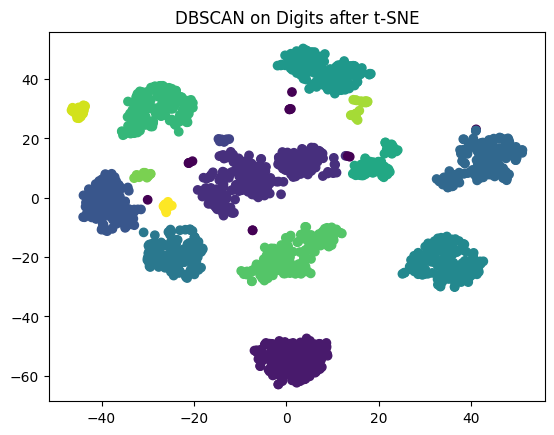

In [20]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

db = DBSCAN(eps=3, min_samples=5)
labels = db.fit_predict(X_tsne)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels)
plt.title("DBSCAN on Digits after t-SNE")
plt.show()

Q41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the
clustering

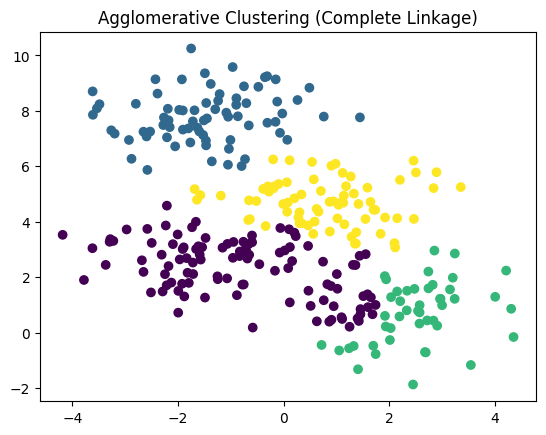

In [21]:
X, _ = make_blobs(n_samples=300, centers=4, random_state=0)

agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

Q42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering.
Visualize in 2D

In [22]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X = load_iris().data
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X_scaled)

noise = list(labels).count(-1)
print("Noise samples:", noise)

Noise samples: 26


Q43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN
side-by-side

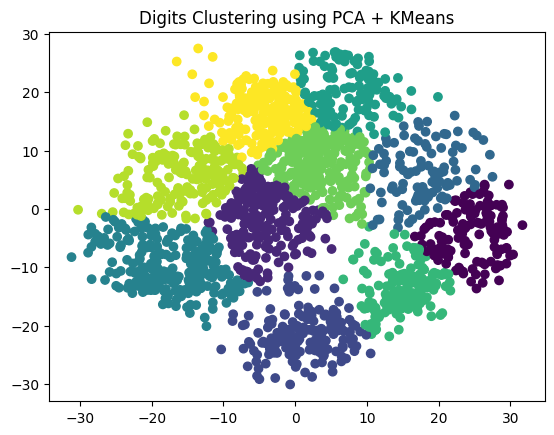

In [23]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data

X_pca = PCA(n_components=2).fit_transform(X)

kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Digits Clustering using PCA + KMeans")
plt.show()

Q44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering

In [24]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

X = load_iris().data

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)

print("First 10 predicted labels:", labels[:10])

First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


Q45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.
Visualize clusters

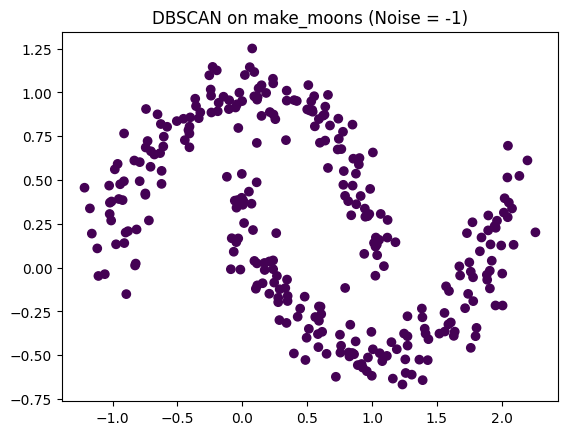

In [25]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.1)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN on make_moons (Noise = -1)")
plt.show()

Q46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4
features)

In [26]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

X = load_wine().data
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

Cluster sizes: {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


Q47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the
count

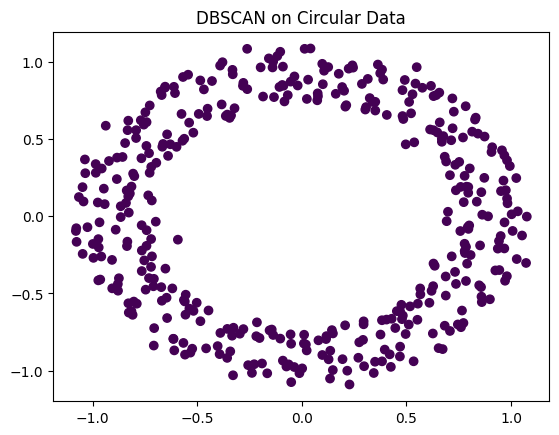

In [27]:
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=400, noise=0.05)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN on Circular Data")
plt.show()

Q48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the
clusters

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

X = load_breast_cancer().data
X_scaled = MinMaxScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

print("Cluster Centroids:\n", kmeans.cluster_centers_)

Cluster Centroids:
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]
